In [2]:
import earthaccess
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

## Download Data 

In [3]:
auth = earthaccess.login(persist=True)

In [4]:
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    # temporal=("2025-07-01", "2025-07-31"),
    temporal=("2025-07-06T19:20:50", "2025-07-06T19:25:49"),
    count=1
)
print(len(results))

1


In [10]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

## Load Dataset

In [6]:
# Load dataset
path = "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0/PACE_HARP2.20250706T192050.L2.CLOUD_GPC.V3_0.nc"
cloud_ds = xr.open_dataset(path, group='geophysical_data')
nav_ds = xr.open_dataset(path, group='geolocation_data')

In [7]:
# Select variable
data = cloud_ds['cloud_bow_droplet_effective_radius']
lon = nav_ds['longitude']
lat = nav_ds['latitude']

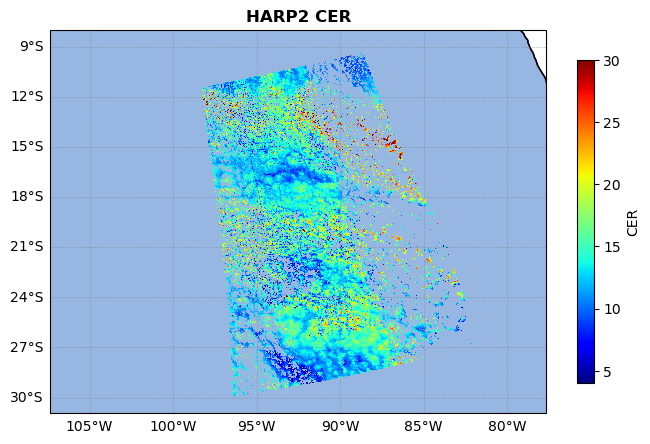

In [8]:
# Plotting
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon, lat, data, vmin=4, vmax=30, cmap='jet', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('CER')

plt.show()

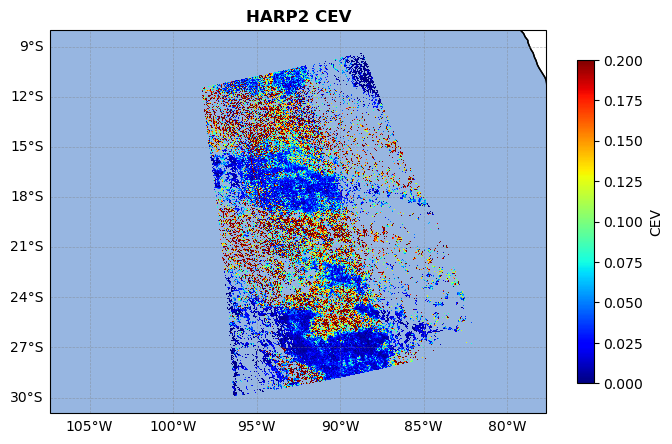

In [10]:
data = cloud_ds['cloud_bow_droplet_effective_variance']

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon, lat, data, vmin=0, vmax=0.2, cmap='jet', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 CEV', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('CEV')

plt.show()

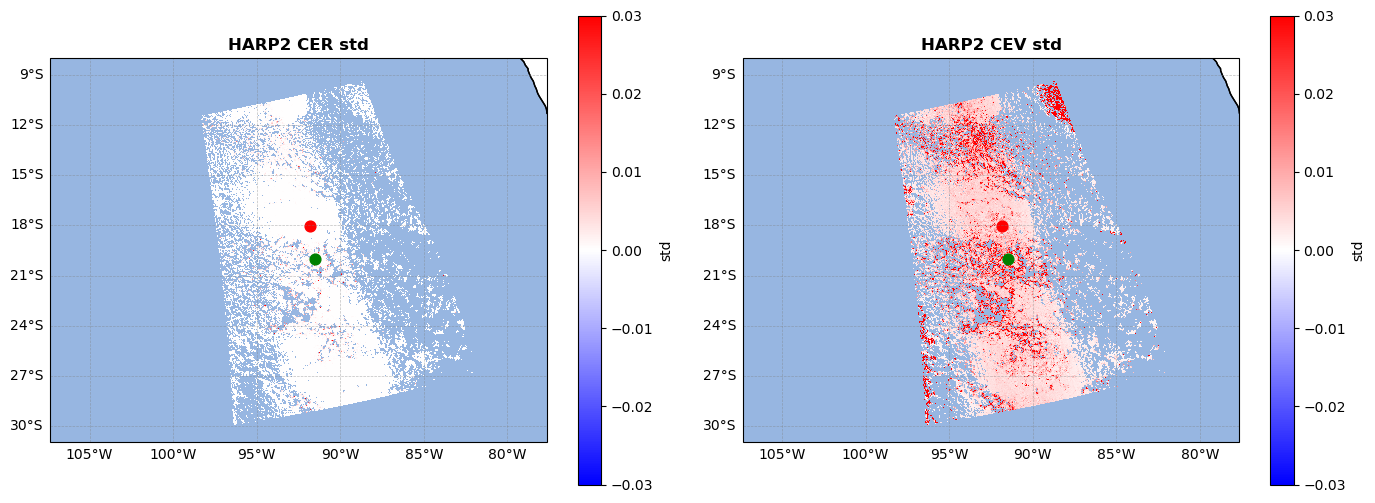

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# To mark two pixels on the map
y0, x0 = 231, 292
y1, x1 = 188, 289
lon0, lat0 = lon[y0, x0], lat[y0, x0]
lon1, lat1 = lon[y1, x1], lat[y1, x1]

# First subplot: CER std
data1 = cloud_ds['cloud_bow_droplet_effective_radius_stddev']
im1 = axes[0].pcolormesh(lon, lat, data1, vmin=-0.03, vmax=0.03, cmap='bwr', shading='auto')
axes[0].coastlines()
axes[0].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
axes[0].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[0].add_feature(cfeature.OCEAN)
axes[0].set_title('HARP2 CER std', fontsize=12, fontweight='bold')

# Mark pixels
axes[0].scatter(lon0, lat0, c='red', marker='o', s=60, transform=ccrs.PlateCarree())
axes[0].scatter(lon1, lat1, c='green', marker='o', s=60, transform=ccrs.PlateCarree())

gl = axes[0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                       color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', shrink=0.7, pad=0.05)
cbar1.set_label('std')

# Second subplot: CEV std
data2 = cloud_ds['cloud_bow_droplet_effective_variance_stddev']
im2 = axes[1].pcolormesh(lon, lat, data2, vmin=-0.03, vmax=0.03, cmap='bwr', shading='auto')
axes[1].coastlines()
axes[1].add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
axes[1].add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
axes[1].add_feature(cfeature.OCEAN)
axes[1].set_title('HARP2 CEV std', fontsize=12, fontweight='bold')

# Mark pixels
axes[1].scatter(lon0, lat0, c='r', marker='o', s=60, transform=ccrs.PlateCarree())
axes[1].scatter(lon1, lat1, c='g', marker='o', s=60, transform=ccrs.PlateCarree())

gl = axes[1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                       color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar2 = plt.colorbar(im2, ax=axes[1], orientation='vertical', shrink=0.7, pad=0.05)
cbar2.set_label('std')

plt.tight_layout()
# plt.savefig("HARP2_CER_CEV_std_with_pixels.png", dpi=500, bbox_inches="tight")
plt.show()

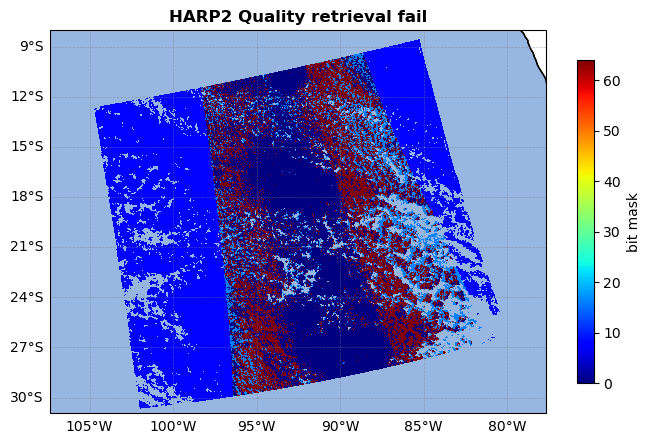

In [13]:
data = cloud_ds['cloud_bow_quality_retrieval_fail']   # bit= 0 means retrieval is ok, bit >0 means failed bits

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
img = ax.pcolormesh(lon, lat, data, cmap='jet', shading='auto')
ax.coastlines()
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')     
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=.8)
ax.add_feature(cfeature.OCEAN)
ax.set_title('HARP2 Quality retrieval fail', fontsize=12, color='k', fontweight='bold')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
# gl.xlines = False
# gl.ylines = False

cbar = plt.colorbar(img, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)
cbar.set_label('bit mask')

# plt.savefig("HARP2 Quality retrieval fail", dpi=500, bbox_inches="tight")
plt.show()

### To plot a line graph (e.g. suface reflectance vs Wavelength)

In [ ]:
ds = xr.open_dataset(path, group='geophysical_data')
wv = xr.open_dataset(path, group='sensor_band_parameters')
print(ds)
print(wv)
# ds.rhos.shape
# wv.wavelength.shape

In [ ]:
# Take a mean across the pixels (or lat, lon) inorder to have same dimension (a single value) 
rhos_mean = ds['rhos'].mean(dim=('number_of_lines', 'pixels_per_line')).values
wavelengths = wv['wavelength'].values

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(wavelengths, rhos_mean, marker='.', linestyle='-', color='b')
plt.xlabel("Wavelength (µm)")
plt.ylabel("Surface Reflectance")
plt.title("Surface Reflectance vs Wavelength", fontsize=12, color="k", fontweight="bold")
plt.grid(True)
# plt.savefig('image.png', dpi=300)
plt.show()